In [ ]:
from pathlib import Path
from lava_network.spiking_dataloader import WISDM_spiking_dataloader, WisdmDatasetParser

from lava_network.output_process import OutputProcess
import numpy as np
from tqdm import tqdm

In [ ]:
from lava.proc.lif.process import LIF
from lava.proc.dense.process import Dense, LearningDense, DelayDense
from lava.utils.weightutils import SignMode
from lava_network.lif_mod import LIFEncoder, RSTDPLIF
from lava_network.dense_mod import DenseEncoder

#path = f"{Path.home()}/snntorch_network/notebook/Trained/network_best.npz"
path = f"{Path.home()}/snntorch_network/nni_experiments/Inibitory_lif_no_encoder/results/hjulef4s/trials/RHEsE/Trained/network_best.npz"
data = np.load(path,allow_pickle=True)


linear1_w= data['linear1']
leaky1_vth= data['leaky1_vth']
leaky1_betas= 1-data['leaky1_betas'] 
leaky1_betas= leaky1_betas if leaky1_betas >= 0 else np.zeros(leaky1_betas.shape)
print(f"leaky1_betas: {leaky1_betas}")
print(f"leaky1_vth: {leaky1_vth}")
linear2_w = data['linear2']
leaky2_vth= data['recurrent_vth']
leaky2_betas= 1 - data['recurrent_betas']
leaky2_betas= leaky2_betas if  leaky2_betas >= 0 else np.zeros(leaky2_betas.shape)
print(f"leaky2_betas: {leaky2_betas}")
print(f"leaky2_vth: {leaky2_vth}")

recurrent_in_weights = data['input_dense']
recurrent_out_weights = - data['output_dense']
recurrent_vth = data['activation_vth']
recurrent_leaky_betas = 1 - data['activation_betas']
recurrent_leaky_betas= recurrent_leaky_betas if recurrent_leaky_betas >= 0 else np.zeros(recurrent_leaky_betas.shape)
print(f"recurrent_leaky_betas: {recurrent_leaky_betas}")
print(f"recurrent_vth: {recurrent_vth}")

linear3_w = data['linear3']
leaky3_vth= data['leaky2_vth']
leaky3_betas= 1 - data['leaky2_betas']
leaky3_betas= leaky3_betas if leaky3_betas >= 0 else np.zeros(leaky3_betas.shape)
print(f"leaky3_betas: {leaky3_betas}")
print(f"leaky3_vth: {leaky3_vth}")


leaky1_betas: 0.8172026127576828
leaky1_vth: 1.711238145828247
leaky2_betas: 0.1649174690246582
leaky2_vth: 0.5812320113182068
recurrent_leaky_betas: 0.13742202520370483
recurrent_vth: 1.1815392971038818
leaky3_betas: 0.0
leaky3_vth: 1.5450438261032104


In [3]:

from lava.magma.core.run_conditions import RunSteps
from lava.magma.core.run_configs import Loihi1SimCfg, Loihi2SimCfg


In [4]:
import json
def deserialize_dict(json_str):
    def convert(obj):
        if isinstance(obj, list):
            return np.array(obj).astype(np.int64)
        if isinstance(obj, int):
            return np.int64(obj)
        return obj
    
    return json.loads(json_str, object_hook=lambda d: {k: convert(v) for k, v in d.items()})


In [5]:
with open('network_fixed.json', 'r') as json_file:
    loaded_json_str = json_file.read()
converted_params = deserialize_dict(loaded_json_str)

In [6]:
total_sample = 2000
signal_step = 40
clear_intervall = 4
train_percentage = 0.6
time_steps = signal_step + clear_intervall

dataset = WisdmDatasetParser('../data/data_watch_subset_0_40.npz', norm=None, class_sublset='custom', subset_list=[0, 4, 6, 8, 9, 10, 14])
val_set = dataset.get_validation_set(shuffle=False, subset=total_sample)
#val_set = dataset.get_validation_set()
train_set = (val_set[0][:int(train_percentage*val_set[0].shape[0])], val_set[1][:int(train_percentage*val_set[0].shape[0])])
val_set = (val_set[0][int(train_percentage*val_set[0].shape[0]):], val_set[1][int(train_percentage*val_set[0].shape[0]):])

num_samples = train_set[0].shape[0]
spiking_loader = WISDM_spiking_dataloader(train_set ,clear_intervall=clear_intervall)
out_sink = OutputProcess(7,num_samples,time_steps, 0)

(6,)
(6,)
ytrain shape (55404, 18)
yval shape (18468, 18)
ytest shape (18469, 18)
num classes train dataset: 7 occurrences of each class:[3127 3044 3102 3047 3150 3087 2973]
num classes eval dataset: 7 occurrences of each class:[1035 1048 1122  996 1110 1053 1007]
num classes test dataset: 7 occurrences of each class:[1046 1048 1046 1036 1076 1026  982]


In [7]:
train_set[1]

array([2, 5, 4, ..., 6, 4, 1])

In [8]:
from lava.proc.learning_rules.r_stdp_learning_rule import RewardModulatedSTDP

R_STDP = RewardModulatedSTDP(learning_rate=1,
                             A_plus=2,
                             A_minus=-1,
                             pre_trace_decay_tau=4,
                             post_trace_decay_tau=4, 
                             pre_trace_kernel_magnitude=4,
                             post_trace_kernel_magnitude=4,
                             eligibility_trace_decay_tau=0.5,
                             t_epoch=4
                             )

In [9]:
linear1 = DenseEncoder(weights=linear1_w, num_message_bits=32, name="linear1")

leaky1 = LIFEncoder(shape=(linear1_w.shape[0],),
                    u = np.zeros(linear1_w.shape[0]),
                    v = np.zeros(linear1_w.shape[0]),
                    du = 1.0,
                    dv = leaky1_betas,
                    vth=leaky1_vth,
                    log_config=0,
                    name= "leaky1"
                )
linear1.a_out.connect(leaky1.a_in)
name = "linear2"
linear2 = Dense(**converted_params[name],
                sign_mode=SignMode.MIXED, name=name)

linear2.s_in.connect_from(leaky1.s_out)

name = "leaky2"
leaky2 = LIF(shape=(linear2_w.shape[0],),
                    **converted_params[name],
                    name= name
                )
#sum.a_out.connect(leaky2.a_in)
linear2.a_out.connect(leaky2.a_in)
#leaky2.a_in.connect_from(linear2.a_out)
name = "recurrent_in"
recurrent_in = Dense(**converted_params[name],
                     name=name)

leaky2.s_out.connect(recurrent_in.s_in)

name = "inibitory_leaky"
ahpc = LIF(shape=(recurrent_in_weights.shape[0],),
                    **converted_params[name],
                    log_config=0,
                    name= name
                )

recurrent_in.a_out.connect(ahpc.a_in)

name = "recurrent_out"
recurrent_out = Dense(**converted_params[name],
                       name=name)
recurrent_out.s_in.connect_from(ahpc.s_out)
recurrent_out.a_out.connect(leaky2.a_in)

name = "linear3"
linear3 = LearningDense(**converted_params[name],
                        learning_rule=R_STDP,
                        name=name)

linear3.s_in.connect_from(leaky2.s_out)
name = "leaky3"
leaky3 = RSTDPLIF(shape=(linear3_w.shape[0],),
                    **converted_params[name],
                    learning_rule=R_STDP,
                    log_config=0,
                    name= name
                )

obj_connection = DelayDense(weights=np.eye(7), name="obj_connection", delays=2)

leaky3.a_in.connect_from(linear3.a_out)

leaky3.s_out.connect(linear3.s_in_bap)
leaky3.s_out_y1.connect(linear3.s_in_y1)
leaky3.s_out_y2.connect(linear3.s_in_y2)


In [10]:
from lava.proc.io.sink import RingBuffer as SinkRingBuffer
from lava.proc.monitor.process import Monitor

weight_update = Monitor()
weight_update.probe(target=linear3.weights, num_steps=num_samples*time_steps)

pre_trace_mon = Monitor()
pre_trace_mon.probe(target=linear3.x1, num_steps=num_samples*time_steps)
post_trace_mon = Monitor()
post_trace_mon.probe(target=linear3.y1, num_steps=num_samples*time_steps)


# monitor_leaky2_u = Monitor()
# monitor_leaky2_u.probe(target=leaky2.v, num_steps=time_steps)

# monitor_leaky3_u = Monitor()
# monitor_leaky3_u.probe(target=leaky3.v, num_steps=time_steps)

# monitor_recurrent_u = Monitor()
# monitor_recurrent_u.probe(target=ahpc.v, num_steps=time_steps)

post_synaptic_trace = SinkRingBuffer(shape=(7,), buffer=num_samples*time_steps)
reward_signal = SinkRingBuffer(shape=(7,), buffer=num_samples*time_steps)
desired_spikes = SinkRingBuffer(shape=(7,),buffer=num_samples*time_steps)
out_buffer = SinkRingBuffer(shape=(7,),buffer=num_samples*time_steps)

leaky3.s_out_y1.connect(post_synaptic_trace.a_in)
leaky3.s_out_y2.connect(reward_signal.a_in)
obj_connection.a_out.connect(desired_spikes.a_in)
leaky3.s_out.connect(out_buffer.a_in)

In [11]:
spiking_loader.data_out.connect(linear1.s_in)
spiking_loader.spike_objective.connect(obj_connection.s_in)
obj_connection.a_out.connect(leaky3.a_third_factor_in)
leaky3.s_out.connect(out_sink.spikes_in)
out_sink.label_in.connect_from(spiking_loader.label_out)

In [12]:
def monitor_extractor(mon):
    data = mon.get_data()
    _ , data = next(iter(data.items()))
    _ , data = next(iter(data.items()))
    return np.array(data)

In [13]:
clock = tqdm(range(num_samples))
for _, i in enumerate(clock):
      out_sink.run(condition=RunSteps(num_steps=time_steps),
                  run_cfg=Loihi1SimCfg(select_sub_proc_model=True,
                  select_tag='fixed_pt'))
      leaky1.v.set(np.zeros(leaky1.v.shape))
      leaky1.u.set(np.zeros(leaky1.u.shape))
      leaky2.v.set(np.zeros(leaky2.v.shape))
      leaky2.u.set(np.zeros(leaky2.u.shape))
      leaky3.v.set(np.zeros(leaky3.v.shape))
      leaky3.u.set(np.zeros(leaky3.u.shape))
      ahpc.v.set(np.zeros(ahpc.v.shape))
      ahpc.u.set(np.zeros(ahpc.u.shape))
      linear1.a_buff.set(np.zeros(linear1.a_buff.shape))
      linear2.a_buff.set(np.zeros(linear2.a_buff.shape))
      linear3.a_buff.set(np.zeros(linear3.a_buff.shape))
      obj_connection.a_buff.set(np.zeros(obj_connection.a_buff.shape))

      tmp_predicition = out_sink.pred_labels.get().astype(int)
      current_accuracy = np.sum((tmp_predicition[:i] == train_set[1][:i])/(i+1))*100
      clock.set_description(f"Current accuracy: {current_accuracy:.4f}")
      updated_weights = linear3.weights.get()

# #weight_update_history = monitor_extractor(weight_update)
# pre_trace_value = monitor_extractor(pre_trace_mon)
# post_synaptic_trace_value = np.array(post_synaptic_trace.data.get())
# reward_signal_value = np.array(reward_signal.data.get())
# desired_spikes_value = np.array(desired_spikes.data.get())
# output_value = np.array(out_buffer.data.get())

# Stop the execution
out_sink.stop()


Current accuracy: 50.5000: 100%|██████████| 1200/1200 [03:51<00:00,  5.17it/s]


In [14]:
import plots

In [15]:
output_value.shape

NameError: name 'output_value' is not defined

In [16]:
desired_spikes_value.shape

(7, 5280)

In [17]:
output_value.shape

(7, 5280)

In [18]:
reward_signal_value.shape

(7, 5280)

In [19]:
print("actual_class", train_set[1])

actual_class [2 5 4 0 1 3 6 1 0 0 0 5 3 3 6 0 4 2 6 1 0 4 5 5 1 4 5 0 4 6 3 2 2 0 3 6 4 5 2 4 3 6 0 6 1 4 2 1 2 0 2 5 2 1 2 4 6 2 1 1 6 3 5 3 5 6 5 4 4 4 4 2 5 0 3 0 4 1 5 0 2 1 4 4 1 6 6 6 0 0 0 0 0 5 3 5 6 0 3 3 4 0 2 2 3 1 2 5 5 5 0 6 3 1 0 1 2 1 2 3]


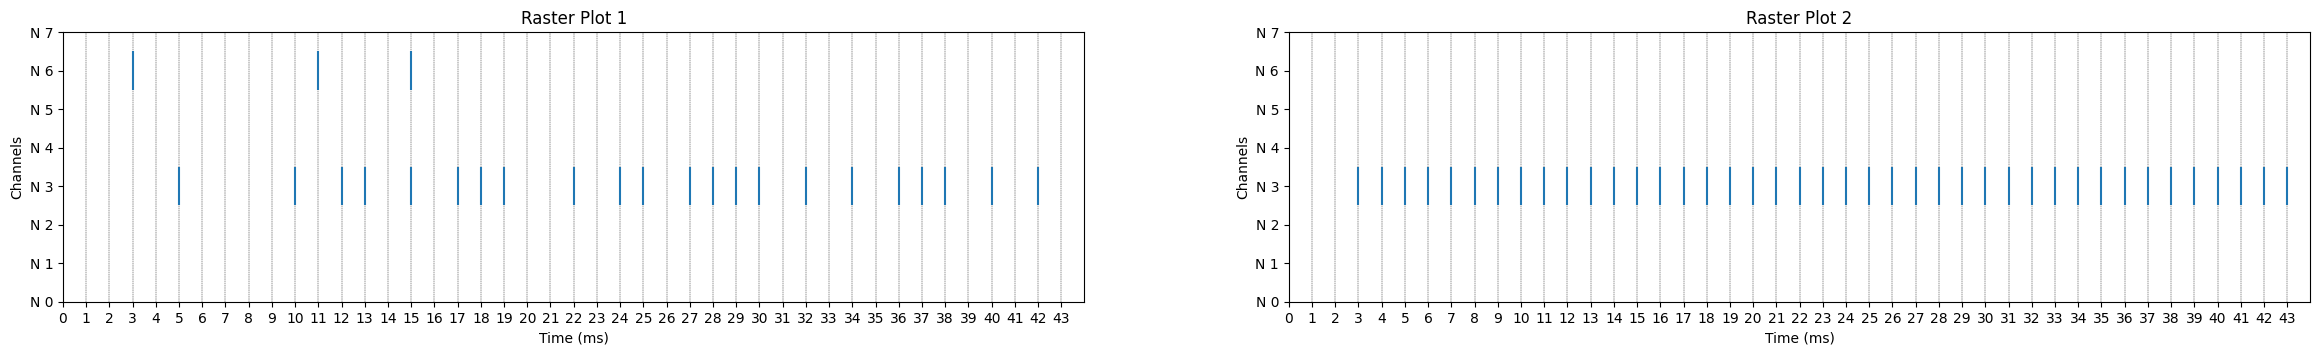

In [20]:
plots.create_raster_plot_subplot(output_value[:, :44], desired_spikes_value[:, :44])


(7, 44)


<Figure size 640x480 with 0 Axes>

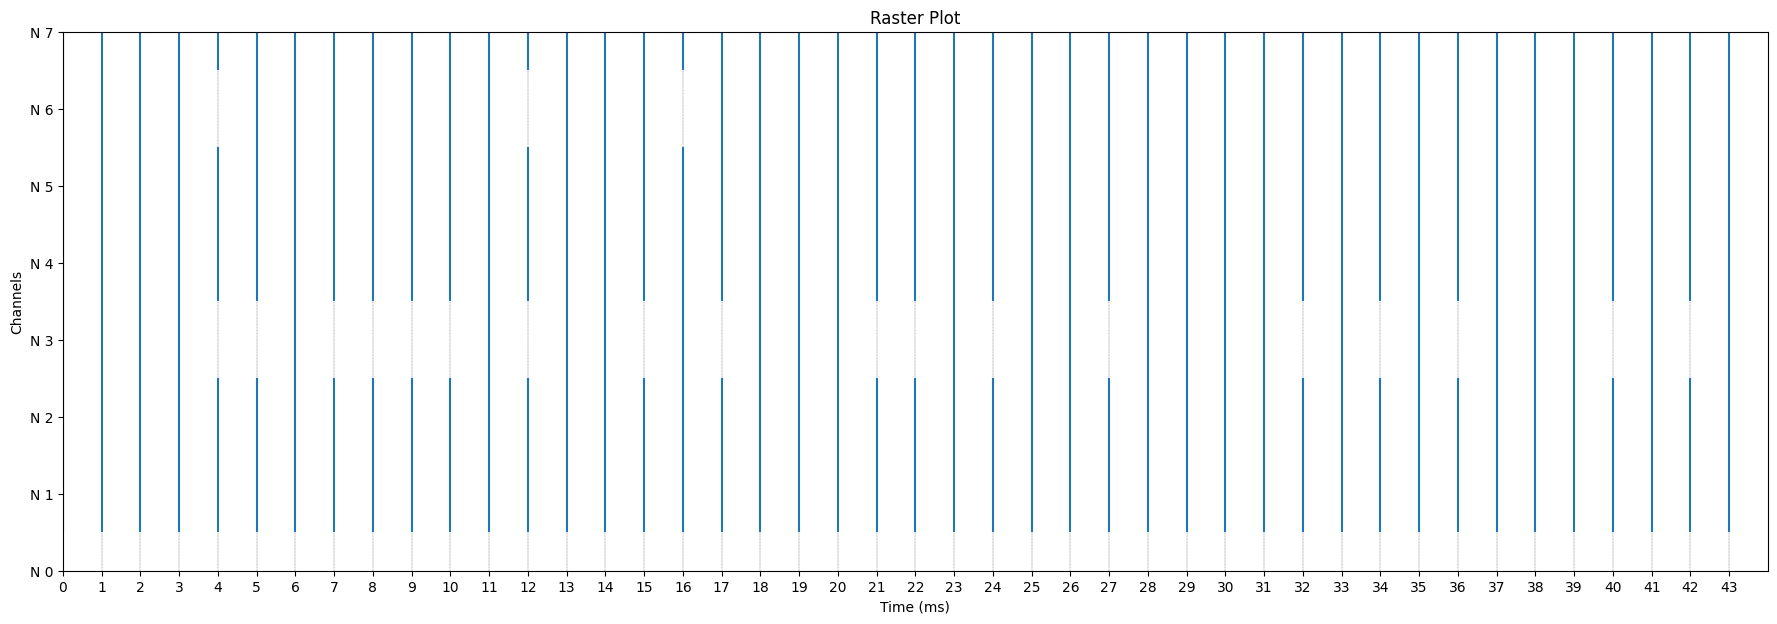

In [21]:
plots.create_raster_plot(reward_signal_value[:, :44])

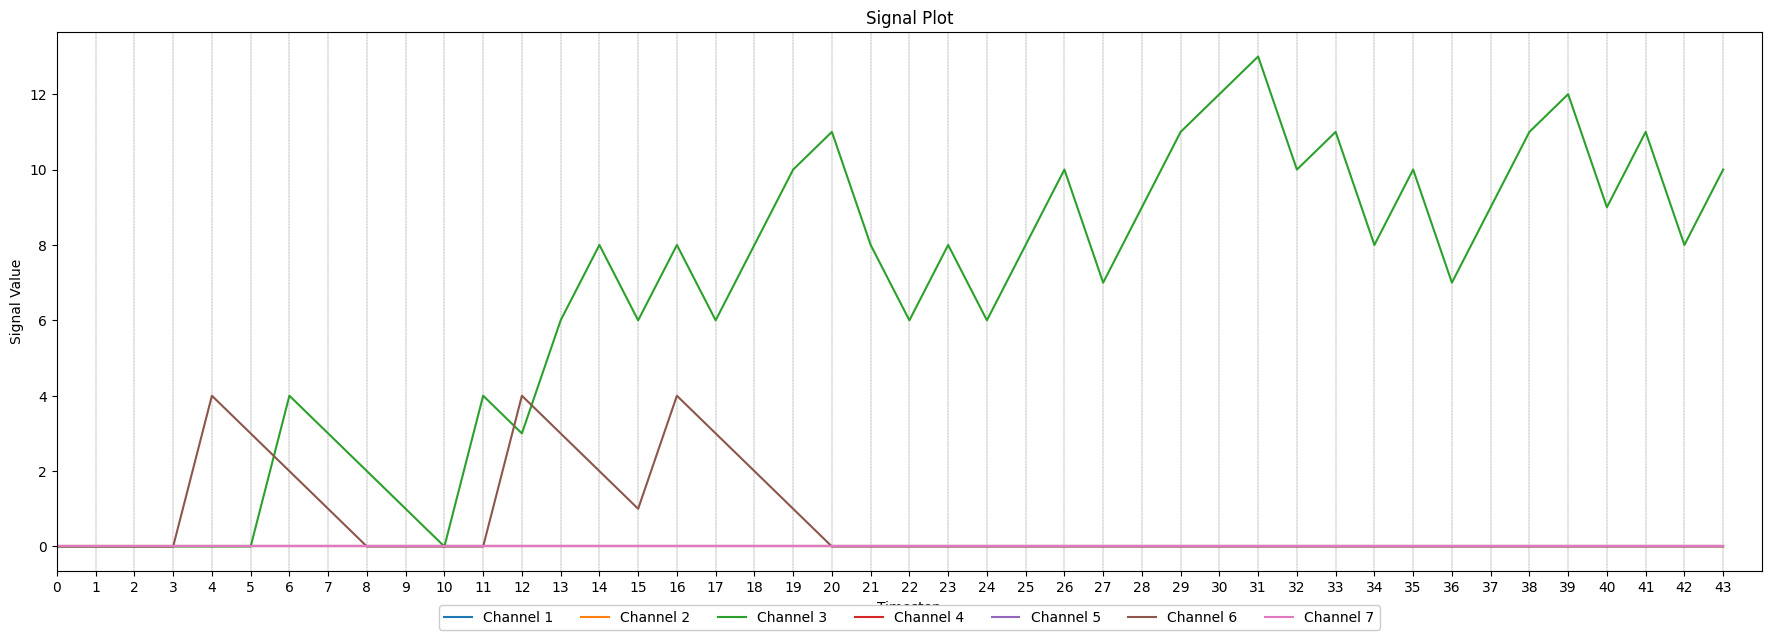

In [22]:
plots.plot_signals(post_synaptic_trace_value[:, :44])

In [23]:
pre_trace_value.shape

(5280, 400)

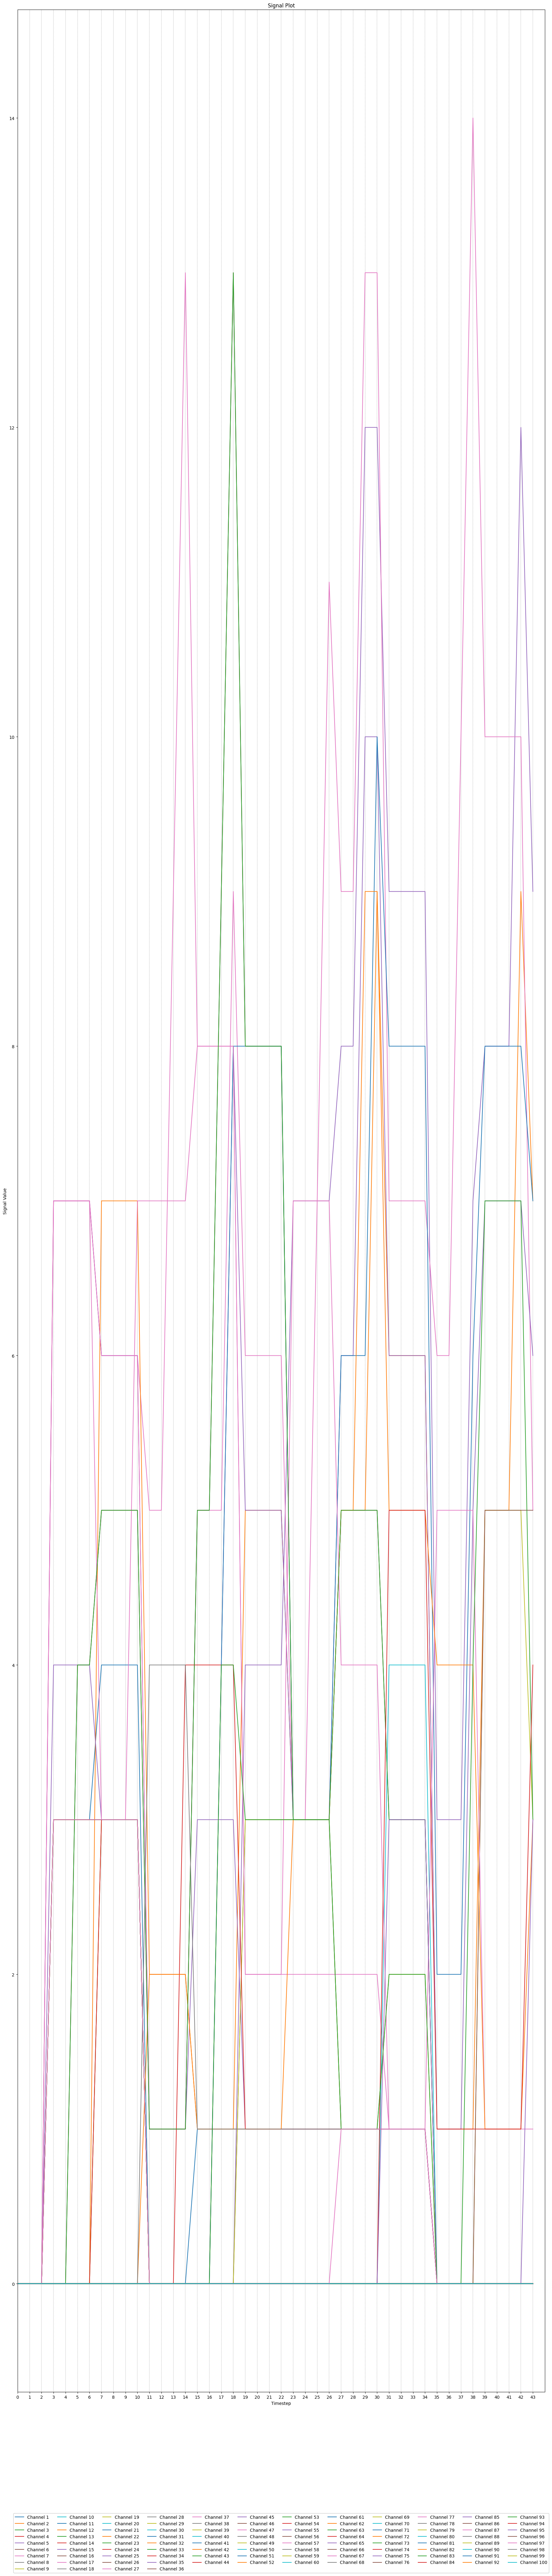

In [24]:
plots.plot_signals(pre_trace_value[:44, :100].T)

In [25]:
weight_update_history.shape

NameError: name 'weight_update_history' is not defined

In [26]:
weight_update_history[:, 1, :].T.shape

(400, 1056)

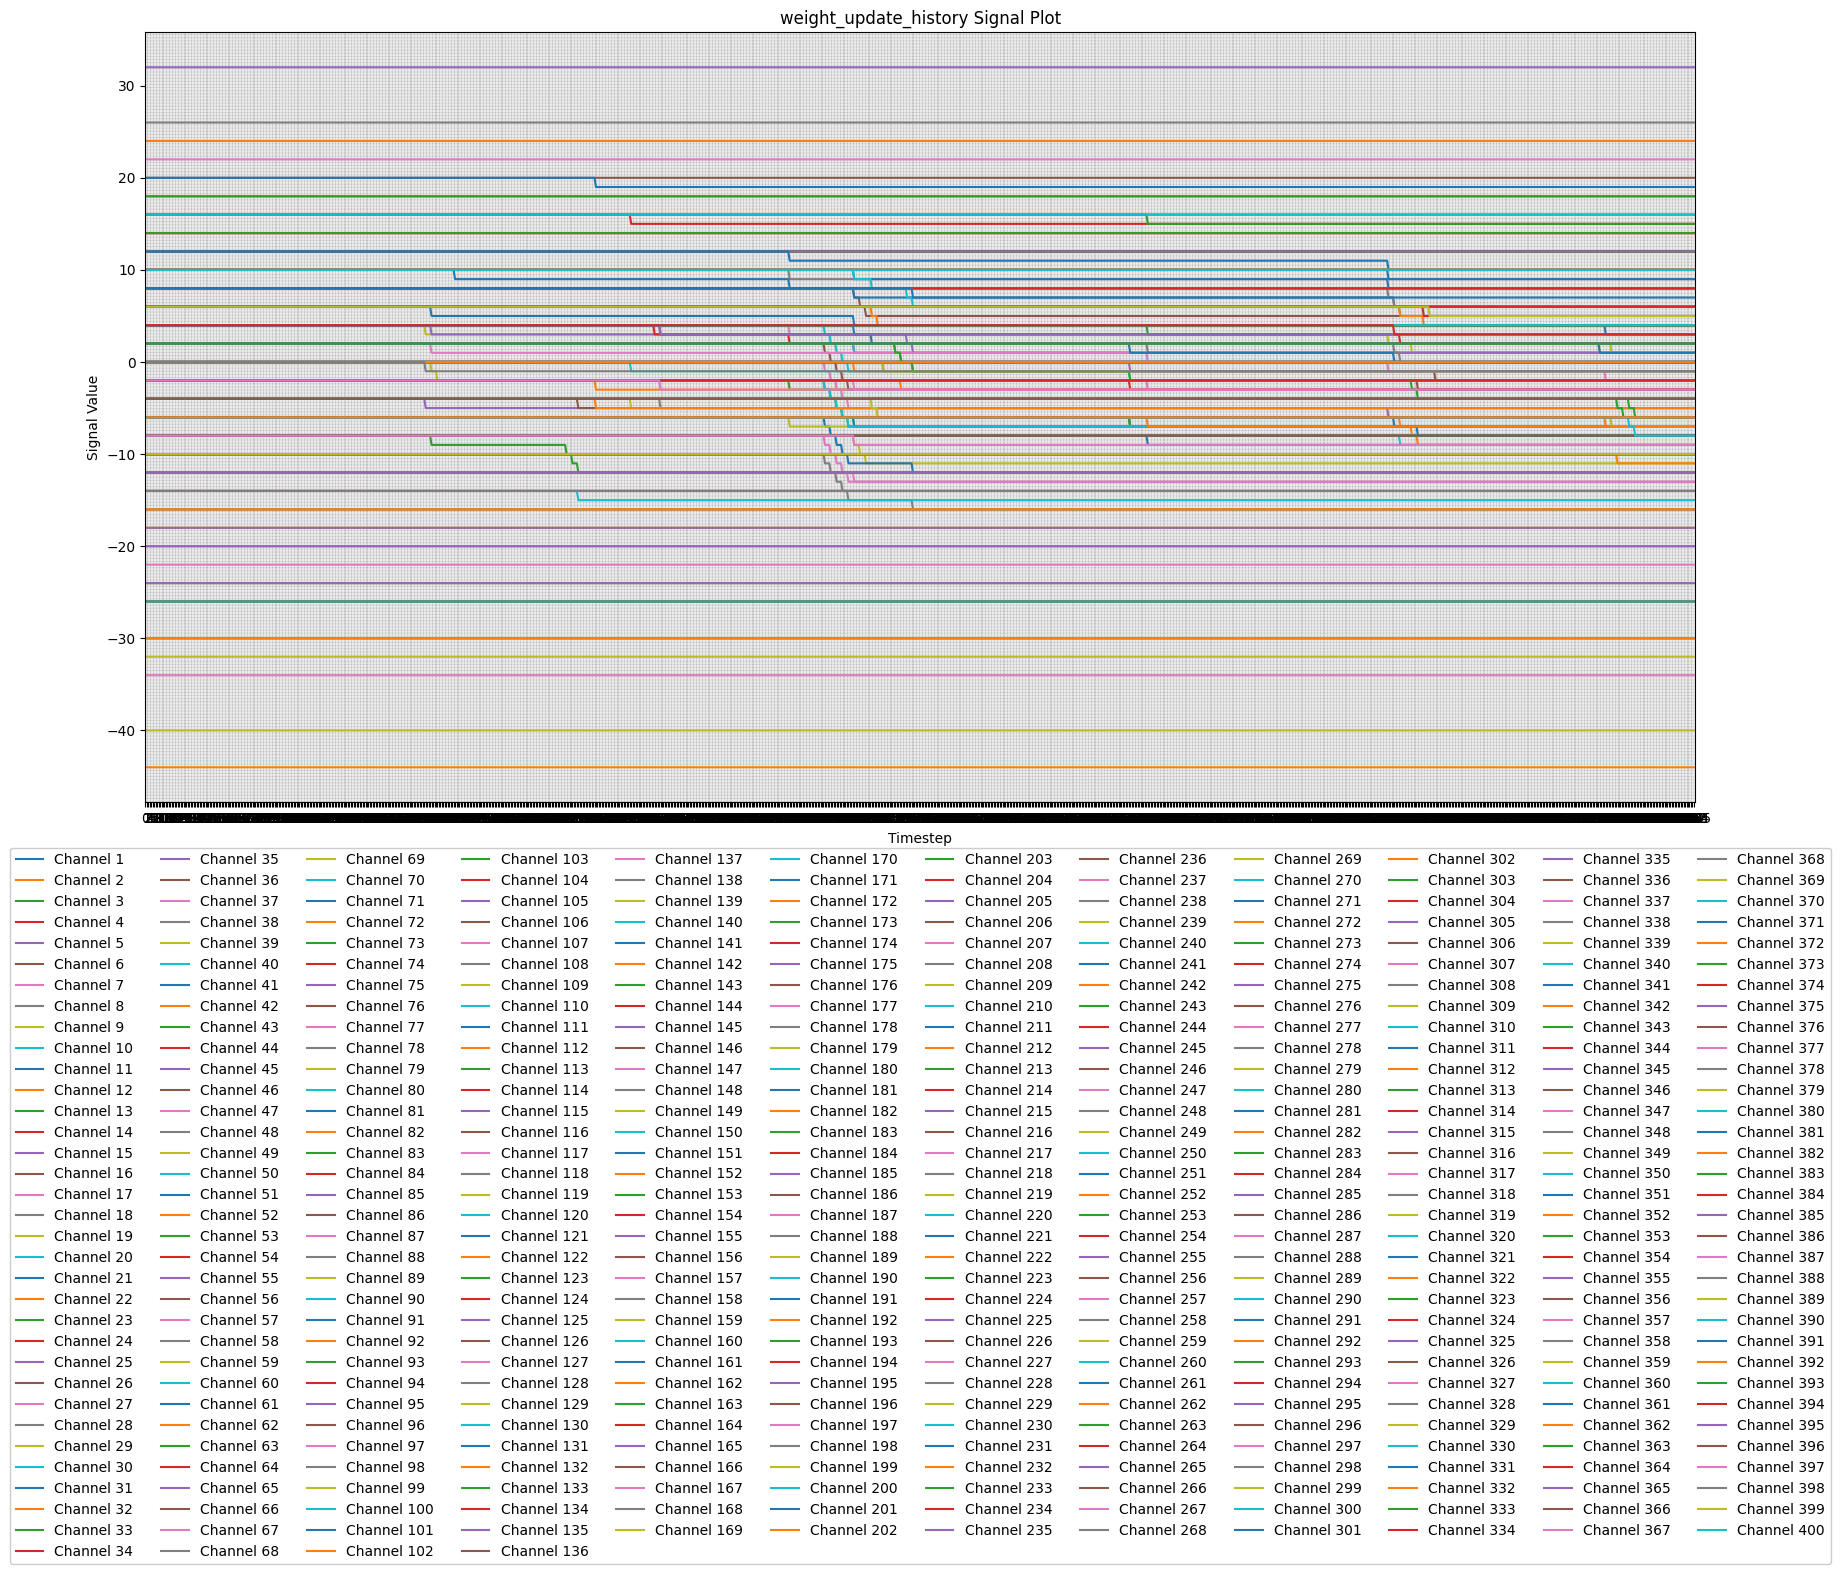

In [27]:
plots.plot_signals(weight_update_history[:, 1, :].T, name="weight_update_history", figsize=(20,10))